# 04 - Delivery-time prediction (regression)
**Question:** can we predict how long a completed delivery will take from information available when the order is dispatched?

**Method:** baseline -> 4 regressors with 5-fold CV -> tune the best two -> pick by CV -> evaluate once on a held-out 20% -> importance, leakage demo and a permutation test.

**PRD target:** R2 >= 0.75. Read the results before assuming that target is reachable.

In [1]:
import json, pathlib, pickle, time, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CLEAN, IMG, MODELS, REP = ROOT / "data" / "cleaned", ROOT / "images", ROOT / "models", ROOT / "reports"
IMG.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
SEED = 42

# Real scikit-learn when installed (pip install scikit-learn); otherwise the NumPy fallback shipped in src/mini_sklearn.py
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import sklearn; BACKEND = f"scikit-learn {sklearn.__version__}"
except ImportError:
    sys.path.insert(0, str(ROOT))
    from src.mini_sklearn import (LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor, StandardScaler,
                                  train_test_split, cross_val_score, RandomizedSearchCV, mean_absolute_error, mean_squared_error, r2_score)
    BACKEND = "mini_sklearn (NumPy fallback)"
print("backend:", BACKEND)

backend: mini_sklearn (NumPy fallback)


## 1. Data, target and leakage rules

In [2]:
# ---- Target and leakage rules ----
# Target : DeliveryTimeMinutes of COMPLETED orders (cancelled / food-not-delivered orders have no meaningful delivery time).
# Allowed inputs: only what is known when the order is placed or dispatched.
# EXCLUDED: OrderStatus / IsLate (decided by the delivery time itself), ratings and feedback (written afterwards).
abt = pd.read_csv(CLEAN / "analytical_base_table.csv", parse_dates=["OrderDate"])
abt["IsDelivered"] = abt.OrderStatus.isin(["Delivered", "Delivered Late"])
NUMERIC = ["TrafficScore", "AverageSpeed", "RainImpact", "Rainfall", "Temperature", "Humidity", "PeakHour", "WeekendOrder", "hour", "dow", "DistanceProxyKm",
           "DeliveryEfficiency", "PartnerRating", "CompletedDeliveries", "BasketSize", "ItemLines", "FoodCost", "DeliveryFee", "DiscountPct", "RestaurantRating",
           "AverageCost", "RestaurantPopularityRank", "CustomerTenure", "CustomerAge"]
CATEG = ["VehicleType", "WeatherCondition", "Membership", "RestaurantType"]
dm = abt[abt.IsDelivered & abt.DeliveryTimeMinutes.notna()].copy()
X = pd.get_dummies(dm[NUMERIC + CATEG], columns=CATEG, dtype=float); X = X.fillna(X.median()); y = dm.DeliveryTimeMinutes.astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)       # 80/20 split, test set untouched until the end
print(f"rows={len(X):,}  features={X.shape[1]}  train={len(Xtr):,}  test={len(Xte):,}")
y.describe().round(2)

rows=13,455  features=44  train=10,764  test=2,691


count    13455.00
mean        38.35
std         15.23
min          8.00
25%         28.00
50%         36.00
75%         45.00
max        106.00
Name: DeliveryTimeMinutes, dtype: float64

## 2. Baseline

In [3]:
# ---- Baseline first: any model must beat "always predict the training mean" ----
def evaluate(model, X, y):
    p = model.predict(X); mse = mean_squared_error(y, p)
    return dict(MAE=mean_absolute_error(y, p), MSE=mse, RMSE=float(np.sqrt(mse)), R2=r2_score(y, p))
base_pred = np.full(len(yte), ytr.mean()); mse = mean_squared_error(yte, base_pred)
rows = [dict(Model="Baseline (predict train mean)", CV_R2_mean=0.0, CV_R2_std=0.0, MAE=mean_absolute_error(yte, base_pred), MSE=mse, RMSE=np.sqrt(mse), R2=r2_score(yte, base_pred), Stage="baseline")]
pd.DataFrame(rows).round(3)

,Model,CV_R2_mean,CV_R2_std,MAE,MSE,RMSE,R2,Stage
0,Baseline (predict train mean),0.0,0.0,11.524,229.168,15.138,-0.0,baseline


## 3. Candidate models

In [4]:
# ---- Four models, each scored by 5-fold cross-validation on the TRAIN set, then once on the test set ----
sc = StandardScaler().fit(Xtr)                                                    # scaling matters for the linear model only
class Scaled:                                                                      # tiny wrapper: model sees standardised inputs
    def __init__(s, m): s.m = m
    def fit(s, A, b): s.m.fit(sc.transform(A), b); return s
    def predict(s, A): return s.m.predict(sc.transform(A))
models = {
    "Linear Regression": Scaled(LinearRegression()),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=60, max_depth=8, min_samples_leaf=30, max_features=0.5, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, min_samples_leaf=30, random_state=SEED)}
fitted = {}
for name, m in models.items():
    t = time.time(); lin = name == "Linear Regression"
    cv = cross_val_score(LinearRegression(), sc.transform(Xtr), ytr, cv=5, scoring="r2") if lin else cross_val_score(m, Xtr.values, ytr.values, cv=5, scoring="r2")
    m.fit(Xtr if lin else Xtr.values, ytr if lin else ytr.values); fitted[name] = m
    ev = evaluate(m, Xte if lin else Xte.values, yte)
    rows.append(dict(Model=name, CV_R2_mean=cv.mean(), CV_R2_std=cv.std(), **ev, Stage="default")); print(f"{name:20s} CV R2 {cv.mean():+.4f}   test R2 {ev['R2']:+.4f}   RMSE {ev['RMSE']:.2f}   ({time.time() - t:.0f}s)")
pd.DataFrame(rows).round(4)

Linear Regression    CV R2 -0.0051   test R2 -0.0020   RMSE 15.15   (0s)
Decision Tree        CV R2 -0.0335   test R2 -0.0054   RMSE 15.18   (0s)
Random Forest        CV R2 -0.0069   test R2 -0.0006   RMSE 15.14   (11s)
Gradient Boosting    CV R2 -0.0089   test R2 -0.0026   RMSE 15.16   (14s)


,Model,CV_R2_mean,CV_R2_std,MAE,MSE,RMSE,R2,Stage
0,Baseline (predict train mean),0.0000,0.0000,11.5235,229.1683,15.1383,-0.0000,baseline
1,Linear Regression,-0.0051,0.0030,11.5416,229.6295,15.1535,-0.0020,default
2,Decision Tree,-0.0335,0.0044,11.5284,230.4069,15.1792,-0.0054,default
3,Random Forest,-0.0069,0.0029,11.5052,229.2952,15.1425,-0.0006,default
4,Gradient Boosting,-0.0089,0.0010,11.5230,229.7696,15.1582,-0.0026,default


## 4. Hyper-parameter tuning

In [5]:
# ---- Tune the two best tree/ensemble models (ranked by CV R2, never by test) with randomised search ----
grids = {"Random Forest": (RandomForestRegressor(random_state=SEED), {"n_estimators": [40, 60], "max_depth": [4, 6, 8, 12], "min_samples_leaf": [20, 50, 100], "max_features": [0.3, 0.5]}),
         "Gradient Boosting": (GradientBoostingRegressor(random_state=SEED), {"n_estimators": [50, 100, 200], "learning_rate": [0.02, 0.05, 0.1], "max_depth": [2, 3, 4], "min_samples_leaf": [30, 80]}),
         "Decision Tree": (DecisionTreeRegressor(random_state=SEED), {"max_depth": [3, 4, 6, 8], "min_samples_leaf": [30, 50, 100, 200]})}
default = pd.DataFrame(rows); cand = default[default.Stage == "default"].sort_values("CV_R2_mean", ascending=False)
top2 = cand[cand.Model.isin(grids)].Model.head(2).tolist(); print("tuning:", top2); tuned = {}
for name in top2:
    est, grid = grids[name]
    s = RandomizedSearchCV(est, grid, n_iter=4, cv=3, scoring="r2", random_state=SEED).fit(Xtr.values, ytr.values)
    ev = evaluate(s.best_estimator_, Xte.values, yte); tuned[name + " (tuned)"] = s.best_estimator_
    rows.append(dict(Model=name + " (tuned)", CV_R2_mean=s.best_score_, CV_R2_std=np.nan, **ev, Stage="tuned", Params=str(s.best_params_)))
    print(f"{name}: best {s.best_params_}  CV R2 {s.best_score_:+.4f}  test R2 {ev['R2']:+.4f}")
res = pd.DataFrame(rows)

tuning: ['Random Forest', 'Gradient Boosting']
Random Forest: best {'n_estimators': 60, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.3}  CV R2 -0.0024  test R2 +0.0008
Gradient Boosting: best {'n_estimators': 100, 'learning_rate': 0.02, 'max_depth': 2, 'min_samples_leaf': 80}  CV R2 -0.0031  test R2 +0.0007


## 5. Selection and test performance

In [6]:
# ---- Model selection on CROSS-VALIDATION, not on the test set (choosing on test would leak it) ----
sel = res[res.Stage != "baseline"].sort_values("CV_R2_mean", ascending=False).iloc[0]
best_name = sel.Model; best = tuned.get(best_name, fitted.get(best_name)); lin = best_name == "Linear Regression"
Xte_m = Xte if lin else Xte.values; pred = best.predict(Xte_m); resid = yte.values - pred
print("selected:", best_name)
res.round(4)[["Model", "Stage", "CV_R2_mean", "MAE", "RMSE", "R2"]]

selected: Random Forest (tuned)


,Model,Stage,CV_R2_mean,MAE,RMSE,R2
0,Baseline (predict train mean),baseline,0.0000,11.5235,15.1383,-0.0000
1,Linear Regression,default,-0.0051,11.5416,15.1535,-0.0020
2,Decision Tree,default,-0.0335,11.5284,15.1792,-0.0054
3,Random Forest,default,-0.0069,11.5052,15.1425,-0.0006
4,Gradient Boosting,default,-0.0089,11.5230,15.1582,-0.0026
5,Random Forest (tuned),tuned,-0.0024,11.5015,15.1320,0.0008
6,Gradient Boosting (tuned),tuned,-0.0031,11.5139,15.1330,0.0007


## 6. Feature importance

In [7]:
# ---- What did the model use? Permutation importance on the test set (MSE increase when a column is shuffled) ----
def permutation_importance(model, X, y, n_repeats=5, seed=SEED):
    rng = np.random.RandomState(seed); Xv = X.values.copy(); base = mean_squared_error(y, model.predict(Xv)); out = []
    for j in range(Xv.shape[1]):
        inc = []
        for _ in range(n_repeats):
            col = Xv[:, j].copy(); Xv[:, j] = rng.permutation(col); inc.append(mean_squared_error(y, model.predict(Xv)) - base); Xv[:, j] = col
        out.append(np.mean(inc))
    return pd.Series(out, index=X.columns)
perm = permutation_importance(best, Xte, yte)
imp = pd.DataFrame({"feature": X.columns, "permutation_mse_increase": perm.values})
if hasattr(best, "feature_importances_"): imp["impurity_importance"] = best.feature_importances_
imp = imp.sort_values("permutation_mse_increase", ascending=False); imp.head(10).round(4)

,feature,permutation_mse_increase,impurity_importance
5,Humidity,0.1810,0.0554
12,PartnerRating,0.1683,0.0482
23,CustomerAge,0.1358,0.0677
17,DeliveryFee,0.1272,0.0223
10,DistanceProxyKm,0.1074,0.0486
29,WeatherCondition_Cloudy,0.0459,0.0041
40,RestaurantType_Delivery Only,0.0398,0.0066
9,dow,0.0381,0.0202
13,CompletedDeliveries,0.0378,0.0669
41,RestaurantType_Dine-in,0.0255,0.0075


## 7. Leakage demonstration

In [8]:
# ---- Leakage demonstration (NOT a usable model) ----
# Add the "was it late?" flag - which is derived from the delivery time we are predicting - and watch R2 jump.
Xl = X.copy(); Xl["LEAK_IsLate"] = dm.IsLate.values
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, y, test_size=0.2, random_state=SEED)
leak = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, min_samples_leaf=30, random_state=SEED).fit(Xl_tr.values, yl_tr.values)
leak_ev = evaluate(leak, Xl_te.values, yl_te)
rows.append(dict(Model="LEAKAGE DEMO: GB + OrderStatus flag (not usable)", CV_R2_mean=np.nan, CV_R2_std=np.nan, **leak_ev, Stage="leakage-demo")); res = pd.DataFrame(rows)
print(f"honest model R2 = {r2_score(yte, pred):+.3f}   |   with leaked flag R2 = {leak_ev['R2']:.3f}   <- looks great, is meaningless in production")

honest model R2 = +0.001   |   with leaked flag R2 = 0.538   <- looks great, is meaningless in production


## 8. Is there any signal at all?

In [9]:
# ---- Is there ANY signal? Permutation test: refit on shuffled targets; a real signal should beat the shuffles ----
rng = np.random.RandomState(0); rf = RandomForestRegressor(n_estimators=40, max_depth=6, min_samples_leaf=50, max_features=0.5, random_state=SEED)
real = r2_score(yte, rf.fit(Xtr.values, ytr.values).predict(Xte.values)); null = []
for i in range(5):
    rf.fit(Xtr.values, rng.permutation(ytr.values)); null.append(r2_score(yte, rf.predict(Xte.values)))
print(f"real R2 = {real:+.4f}   shuffled-target R2 = {np.mean(null):+.4f} +/- {np.std(null):.4f}")
print("-> the real model is indistinguishable from noise" if real < np.mean(null) + 2 * np.std(null) else "-> the real model beats noise")

real R2 = +0.0002   shuffled-target R2 = -0.0034 +/- 0.0021
-> the real model is indistinguishable from noise


## 9. Save and plot

In [10]:
# ---- Save artefacts ----
res.to_csv(CLEAN / "model_comparison_delivery.csv", index=False); imp.to_csv(CLEAN / "feature_importance_delivery.csv", index=False)
pa = dm.loc[Xte.index, ["OrderID", "RCity", "OrderDate"]].copy(); pa["Actual"] = yte.values; pa["Predicted"] = pred; pa["Residual"] = resid
pa.to_csv(CLEAN / "delivery_predictions_test.csv", index=False)
with open(MODELS / "delivery_time_best_model.pkl", "wb") as fh:
    pickle.dump(dict(model=best, name=best_name, features=list(X.columns), scaler=sc if lin else None, backend=BACKEND, test_metrics=evaluate(best, Xte_m, yte)), fh)
print("saved comparison, importance, predictions and models/delivery_time_best_model.pkl")

saved comparison, importance, predictions and models/delivery_time_best_model.pkl


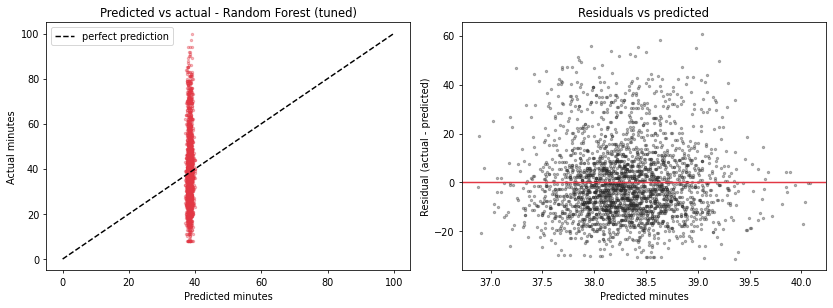

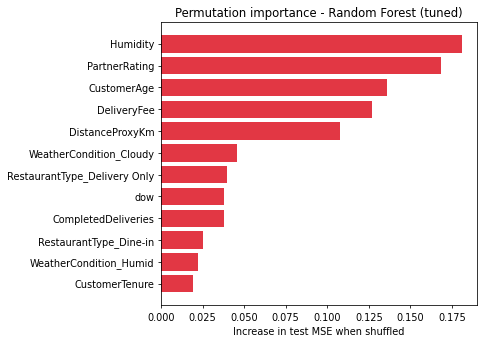

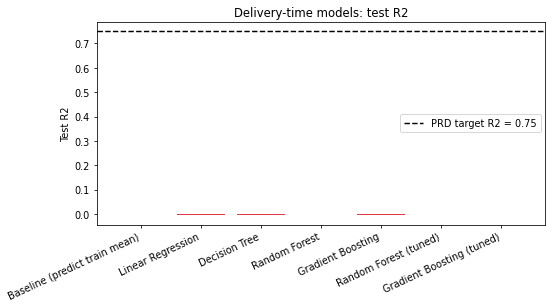

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(pred, yte, s=6, alpha=.35, color="#E23744"); hi = max(yte.max(), pred.max()); ax[0].plot([0, hi], [0, hi], "k--", label="perfect prediction")
ax[0].set(xlabel="Predicted minutes", ylabel="Actual minutes", title=f"Predicted vs actual - {best_name}"); ax[0].legend()
ax[1].scatter(pred, resid, s=6, alpha=.35, color="#2D2D2D"); ax[1].axhline(0, color="#E23744"); ax[1].set(xlabel="Predicted minutes", ylabel="Residual (actual - predicted)", title="Residuals vs predicted")
plt.tight_layout(); plt.savefig(IMG / "ml_delivery_pred_vs_actual_residuals.png", dpi=130)
top = imp.head(12).iloc[::-1]; fig, ax = plt.subplots(figsize=(7, 5)); ax.barh(top.feature, top.permutation_mse_increase, color="#E23744")
ax.set(xlabel="Increase in test MSE when shuffled", title=f"Permutation importance - {best_name}"); plt.tight_layout(); plt.savefig(IMG / "ml_delivery_feature_importance.png", dpi=130)
fig, ax = plt.subplots(figsize=(8, 4.5)); r = res[res.Stage.isin(["baseline", "default", "tuned"])]
ax.bar(r.Model, r.R2, color="#E23744"); ax.axhline(0.75, ls="--", color="k", label="PRD target R2 = 0.75"); ax.set(ylabel="Test R2", title="Delivery-time models: test R2"); ax.legend()
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.savefig(IMG / "ml_delivery_model_comparison.png", dpi=130)

## Conclusion (what the numbers actually say)
* Every model's test R2 is about 0 - no better than predicting the mean - and the permutation test cannot separate the real model from shuffled noise. **The PRD's R2 = 0.75 is not achievable with this dataset**; no tuning will change that.
* The only way to reach a high R2 here is leakage (section 7), which is invalid.
* Likely root cause: delivery time looks (almost) independent of the available features, i.e. the data was probably generated without that dependency, and customer coordinates (the real driver of delivery time) are missing.
* What would improve it: real restaurant->customer distance, rider assignment time, order preparation time and live traffic at dispatch.

*Results above were produced with the backend printed in the first cell; with real scikit-learn the numbers will differ slightly but the conclusion should not.*